In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np

import warnings
warnings.filterwarnings("ignore")

Cards = pd.read_csv("./data/cards_data.csv")
Transactions = pd.read_csv("./data/transactions_data.csv")
Users = pd.read_csv("./data/users_data.csv")

In [8]:
Cards.head()

,id,client_id,card_brand,card_type,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed,card_on_dark_web
0,4524,825,Visa,Debit,4344676511950444,12/2022,623,YES,2,$24295,09/2002,2008,No
1,2731,825,Visa,Debit,4956965974959986,12/2020,393,YES,2,$21968,04/2014,2014,No
2,3701,825,Visa,Debit,4582313478255491,02/2024,719,YES,2,$46414,07/2003,2004,No
3,42,825,Visa,Credit,4879494103069057,08/2024,693,NO,1,$12400,01/2003,2012,No
4,4659,825,Mastercard,Debit (Prepaid),5722874738736011,03/2009,75,YES,1,$28,09/2008,2009,No


In [9]:
Transactions.head()

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors
0,7475327,2010-01-01 00:01:00,1556,2972,$-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,5499,NaN
1,7475328,2010-01-01 00:02:00,561,4575,$14.57,Swipe Transaction,67570,Bettendorf,IA,52722.0,5311,NaN
2,7475329,2010-01-01 00:02:00,1129,102,$80.00,Swipe Transaction,27092,Vista,CA,92084.0,4829,NaN
3,7475331,2010-01-01 00:05:00,430,2860,$200.00,Swipe Transaction,27092,Crown Point,IN,46307.0,4829,NaN
4,7475332,2010-01-01 00:06:00,848,3915,$46.41,Swipe Transaction,13051,Harwood,MD,20776.0,5813,NaN


In [10]:
Users.head()

,id,current_age,retirement_age,birth_year,birth_month,gender,address,latitude,longitude,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards
0,825,53,66,1966,11,Female,462 Rose Lane,34.15,-117.76,$29278,$59696,$127613,787,5
1,1746,53,68,1966,12,Female,3606 Federal Boulevard,40.76,-73.74,$37891,$77254,$191349,701,5
2,1718,81,67,1938,11,Female,766 Third Drive,34.02,-117.89,$22681,$33483,$196,698,5
3,708,63,63,1957,1,Female,3 Madison Street,40.71,-73.99,$163145,$249925,$202328,722,4
4,1164,43,70,1976,9,Male,9620 Valley Stream Drive,37.76,-122.44,$53797,$109687,$183855,675,1


In [ ]:
# 清洗資料
Cards['credit_limit'] = Cards['credit_limit'].replace(r'[\$,]', '', regex=True).astype(float)
Users['yearly_income'] = Users['yearly_income'].replace(r'[\$,]', '', regex=True).astype(float)
Users['total_debt'] = Users['total_debt'].replace(r'[\$,]', '', regex=True).astype(float)
Users['per_capita_income'] = Users['per_capita_income'].replace(r'[\$,]', '', regex=True).astype(float)
Transactions['amount'] = Transactions['amount'].replace(r'[\$,]', '', regex=True).astype(float)

Trans_merge = Transactions.merge(Cards, left_on="card_id", right_on="id", suffixes=("_txn","_card"))
Trans_merge = Trans_merge.merge(Users, left_on="client_id_txn", right_on="id", suffixes=("","_user"))

Trans_merge['date'] = pd.to_datetime(Trans_merge['date'])
Trans_merge['hour'] = Trans_merge['date'].dt.hour
Trans_merge['date_only'] = Trans_merge['date'].dt.date
Trans_merge['weekday'] = Trans_merge['date'].dt.weekday
Trans_merge['date_hour'] = Trans_merge['date'].dt.floor('h')
Trans_merge['date_5min'] = Trans_merge['date'].dt.floor('5min')

Trans_merge = Trans_merge.drop(['card_number', 'cvv', 'card_on_dark_web'], axis=1)

print(Trans_merge.describe(include='all'))
print(Trans_merge.head(10))

# 基礎統計

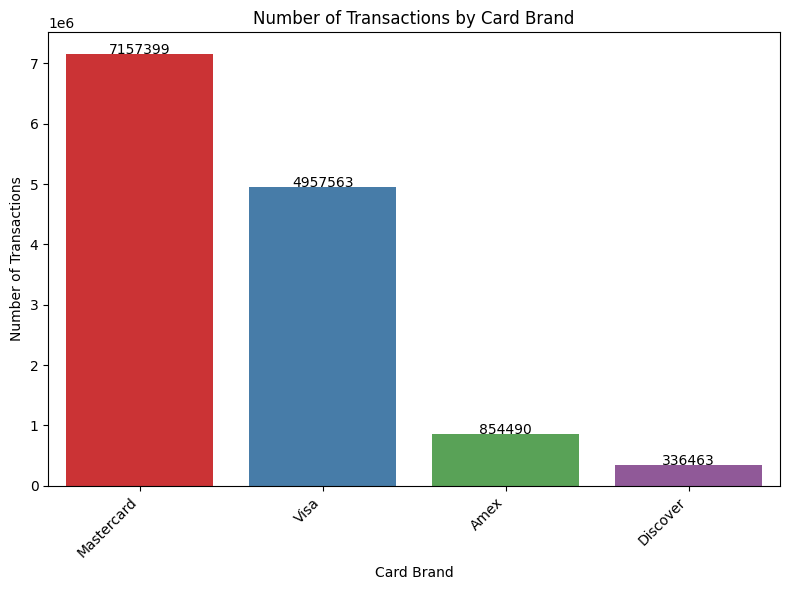

In [34]:
# 使用卡片種類統計
counts = Trans_merge['card_brand'].value_counts()

plt.figure(figsize=(8,6))
colors = sns.color_palette("Set1", n_colors=len(counts))
sns.barplot(x=counts.index, y=counts.values, palette=colors, legend=False)

for i, v in enumerate(counts.values):
    plt.text(i, v + 50, f"{v}", ha='center')

plt.title("Number of Transactions by Card Brand")
plt.xlabel("Card Brand")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
plt.close()

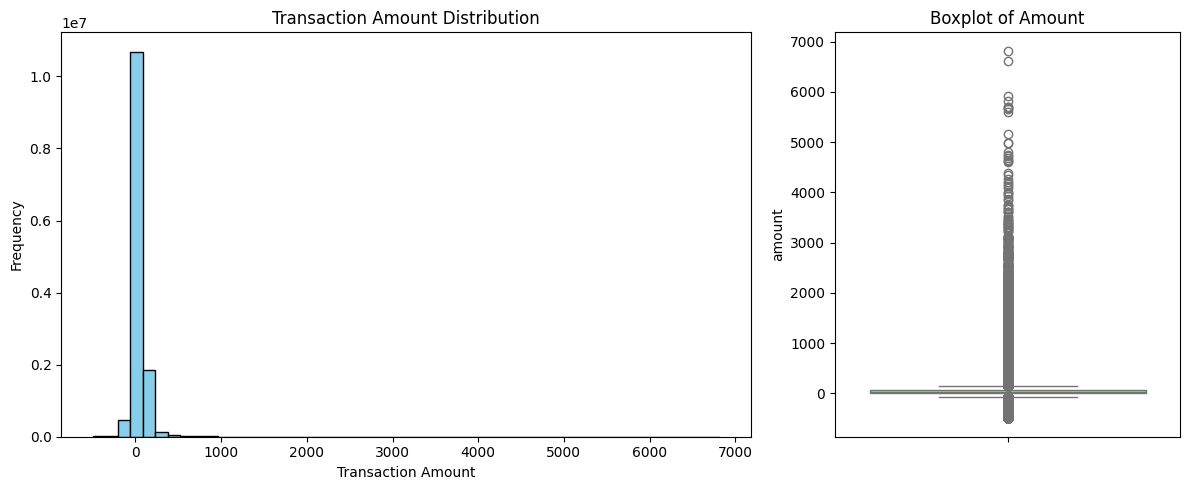

In [20]:
# 交易金額分布與箱型圖
fig, axes = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={'width_ratios': [2, 1]})
axes[0].hist(Trans_merge['amount'], bins=50, color='skyblue', edgecolor='black')
axes[0].set_xlabel('Transaction Amount')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Transaction Amount Distribution')
sns.boxplot(y=Trans_merge['amount'], ax=axes[1], color='lightgreen')
axes[1].set_title('Boxplot of Amount')
plt.tight_layout()
plt.show()
plt.close()

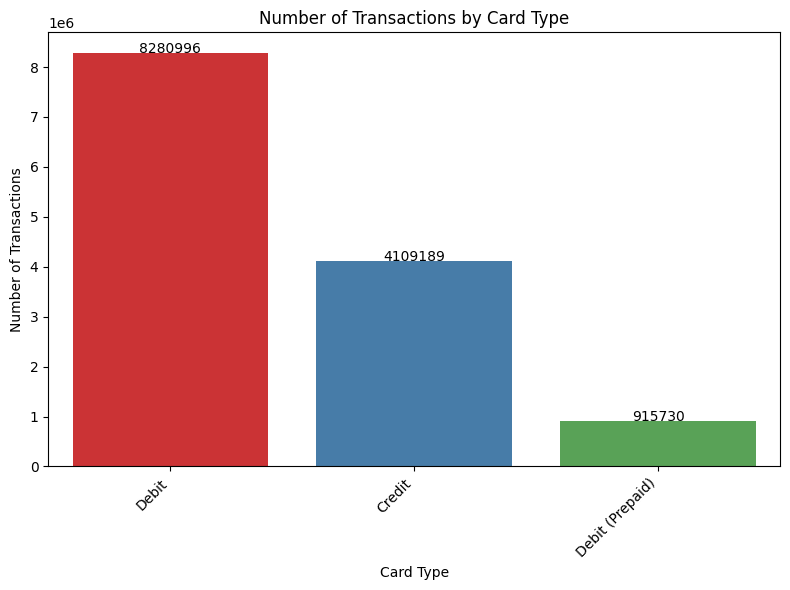

In [32]:
# 各卡片類型交易數量長條圖
counts = Trans_merge['card_type'].value_counts()
plt.figure(figsize=(8,6))
sns.barplot(x=counts.index, y=counts.values, palette="Set1")
for i, v in enumerate(counts.values):
    plt.text(i, v + 50, f"{v}", ha='center')
plt.title("Number of Transactions by Card Type")
plt.xlabel("Card Type")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
plt.close()

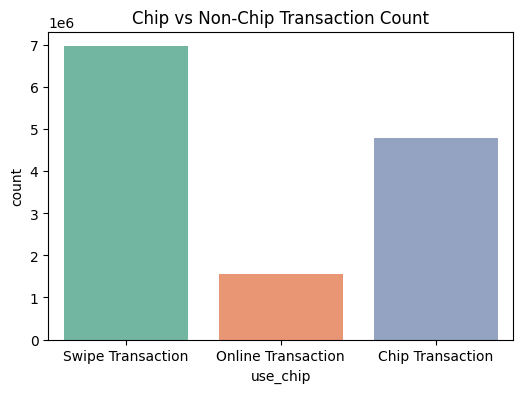

In [33]:
# 晶片卡與非晶片卡交易數量
plt.figure(figsize=(6,4))
sns.countplot(x="use_chip", data=Trans_merge, palette="Set2")
plt.title("Chip vs Non-Chip Transaction Count")
plt.show()
plt.close()

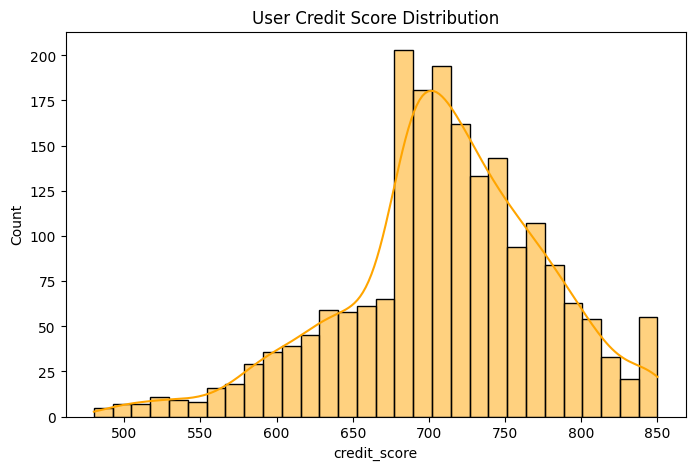

In [23]:
# 用戶信用分數分布
plt.figure(figsize=(8,5))
sns.histplot(Users['credit_score'], bins=30, kde=True, color="orange")
plt.title("User Credit Score Distribution")
plt.show()
plt.close()

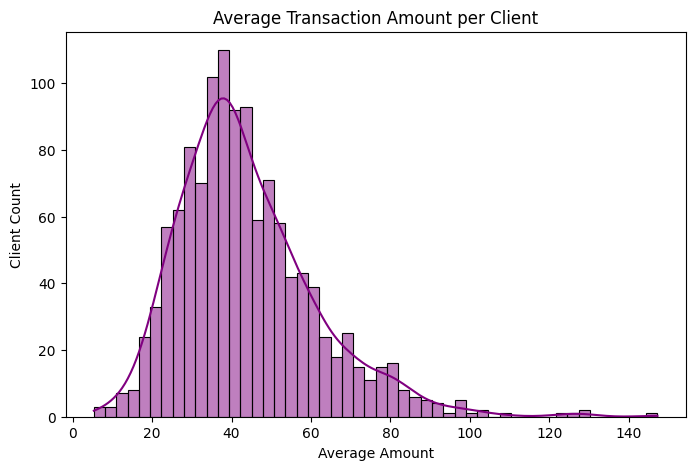

In [24]:
# 每位用戶平均交易金額分布
avg_amount = Trans_merge.groupby("client_id_txn")['amount'].mean()
plt.figure(figsize=(8,5))
sns.histplot(avg_amount, bins=50, kde=True, color="purple")
plt.title("Average Transaction Amount per Client")
plt.xlabel("Average Amount")
plt.ylabel("Client Count")
plt.show()
plt.close()

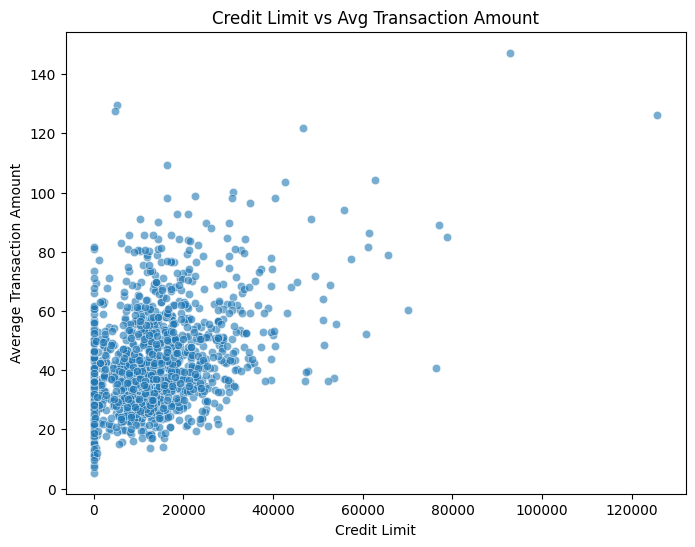

In [25]:
# 信用額度與平均交易金額散點圖
client_summary = Trans_merge.groupby("client_id_txn").agg({
    'amount':'mean',
    'credit_limit':'first'
}).reset_index()
plt.figure(figsize=(8,6))
sns.scatterplot(x="credit_limit", y="amount", data=client_summary, alpha=0.6)
plt.title("Credit Limit vs Avg Transaction Amount")
plt.xlabel("Credit Limit")
plt.ylabel("Average Transaction Amount")
plt.show()
plt.close()

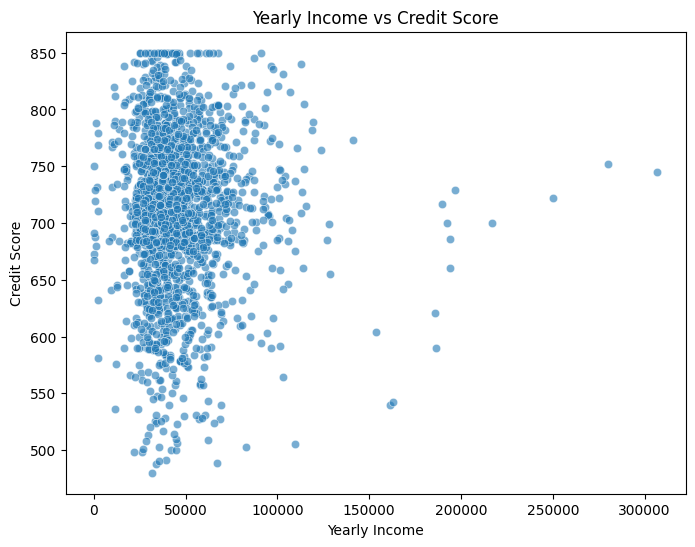

In [31]:
# 年收入與信用分數散點圖
plt.figure(figsize=(8,6))
sns.scatterplot(x="yearly_income", y="credit_score", data=Users, alpha=0.6)
plt.title("Yearly Income vs Credit Score")
plt.xlabel("Yearly Income")
plt.ylabel("Credit Score")
plt.show()
plt.close()

# 高交易量的客戶查找與分析
**接下來，針對高交易量的客戶進行查找與分析**

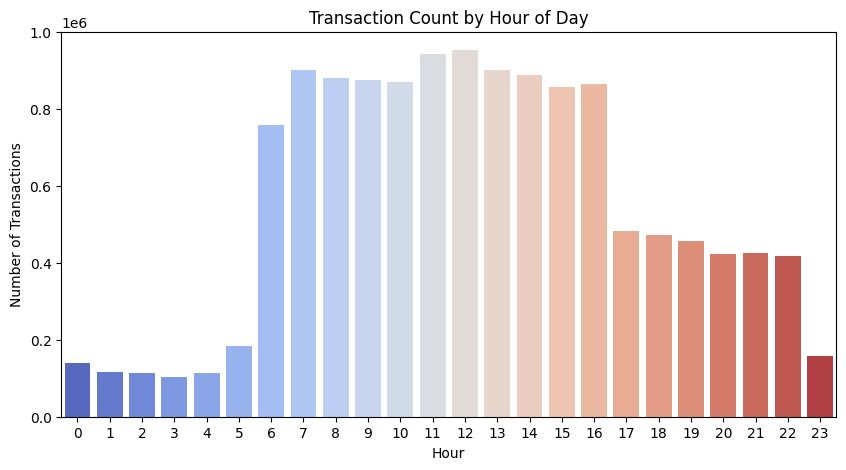

In [37]:
# 每小時交易計數圖
plt.figure(figsize=(10,5))
sns.countplot(x='hour', data=Trans_merge, palette='coolwarm')
plt.title("Transaction Count by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Transactions")
plt.show()
plt.close()

In [39]:
# 每次最高交易
daily_counts = Trans_merge.groupby(['client_id_txn','date_only']).size().reset_index(name='txn_count')
suspicious_daily = daily_counts[daily_counts['txn_count'] > 5]
print("Clients with more than 5 transactions per day:")
print(suspicious_daily.head(10))

Clients with more than 5 transactions per day:
    client_id_txn   date_only  txn_count
6               0  2010-01-07          6
8               0  2010-01-09          9
15              0  2010-01-16          7
30              0  2010-02-02          6
37              0  2010-02-09         13
47              0  2010-02-21         11
60              0  2010-03-06          7
62              0  2010-03-08          7
69              0  2010-03-15          6
73              0  2010-03-19          6


In [40]:
# 每小時交易量最高
hourly_counts = Trans_merge.groupby(['client_id_txn','date_hour']).size().reset_index(name='txn_count')
suspicious_hourly = hourly_counts[hourly_counts['txn_count'] > 3]
print("Clients with more than 3 transactions per hour:")
print(suspicious_hourly.head(10))

Clients with more than 3 transactions per hour:
      client_id_txn           date_hour  txn_count
24                0 2010-01-09 13:00:00          4
100               0 2010-02-09 12:00:00          7
324               0 2010-05-06 13:00:00          4
573               0 2010-08-08 12:00:00          6
848               0 2010-12-06 12:00:00          4
982               0 2011-01-29 12:00:00          4
992               0 2011-02-01 12:00:00          4
1015              0 2011-02-06 19:00:00          4
1066              0 2011-02-23 22:00:00          4
1146              0 2011-03-23 12:00:00          4


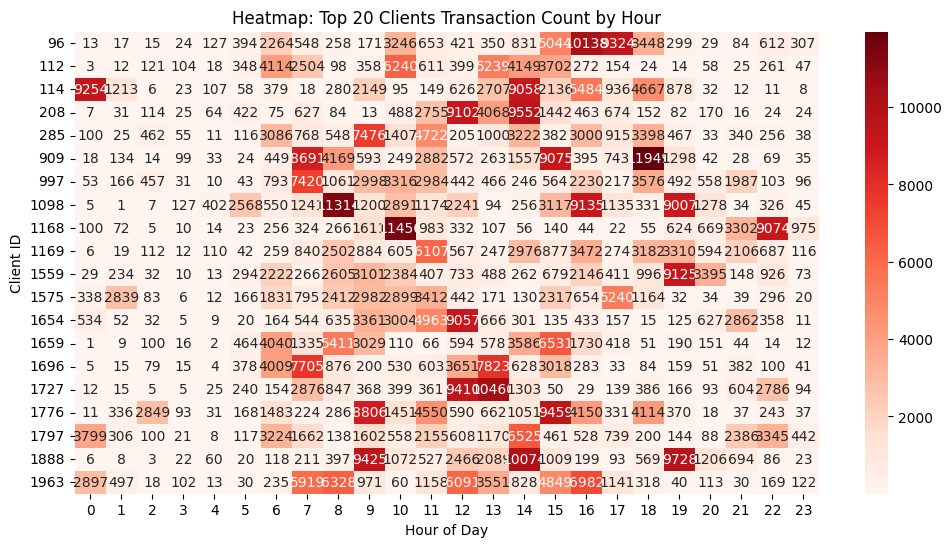

In [41]:
# 交易量前 20 名客戶的熱力圖
top_clients = Trans_merge['client_id_txn'].value_counts().head(20).index
heatmap_data = Trans_merge[Trans_merge['client_id_txn'].isin(top_clients)]
heatmap_data = heatmap_data.groupby(['client_id_txn', 'hour']).size().unstack(fill_value=0)

plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data, cmap='Reds', annot=True, fmt="d")
plt.title("Heatmap: Top 20 Clients Transaction Count by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Client ID")
plt.show()

plt.close()

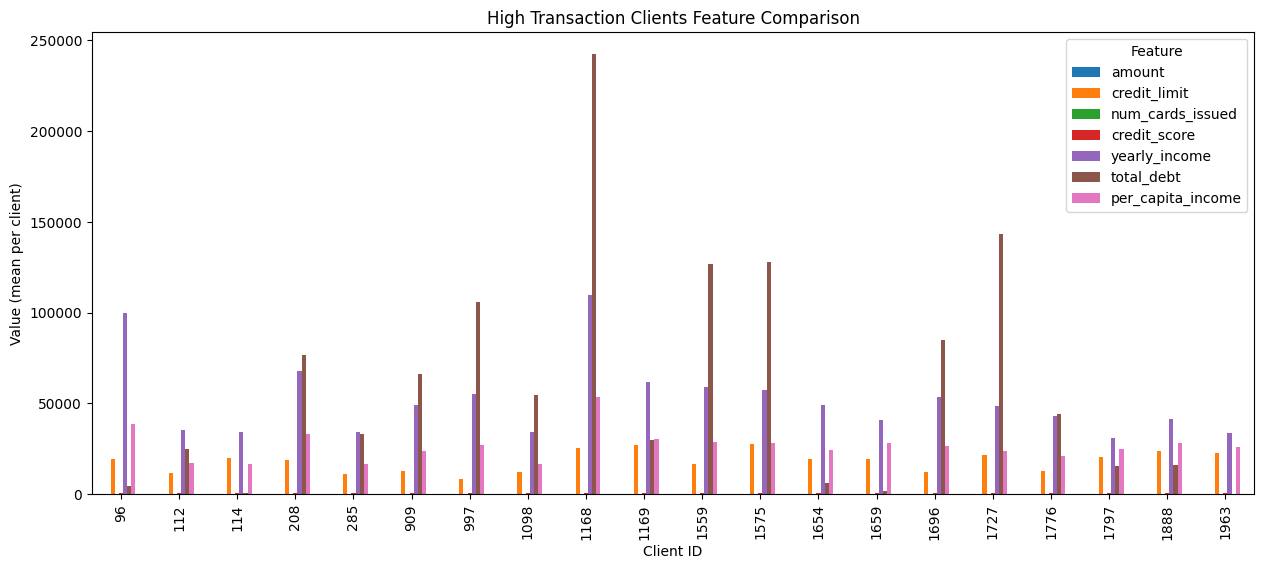

In [43]:
# TOP 20 客戶的特徵比較
client_txn_counts = Trans_merge['client_id_txn'].value_counts()
top_clients = client_txn_counts.head(20).index
top_client_data = Trans_merge[Trans_merge['client_id_txn'].isin(top_clients)]

agg_features = top_client_data.groupby('client_id_txn').agg({
    'amount': 'mean',
    'credit_limit': 'mean',
    'num_cards_issued': 'mean',
    'credit_score': 'mean',
    'yearly_income': 'mean',
    'total_debt': 'mean',
    'per_capita_income': 'mean'
}).reset_index()

features = [
    'amount',
    'credit_limit',
    'num_cards_issued',
    'credit_score',
    'yearly_income',
    'total_debt',
    'per_capita_income'
]

agg_features_top = agg_features.set_index('client_id_txn')
agg_features_top.plot(kind='bar', figsize=(15,6))
plt.title("High Transaction Clients Feature Comparison")
plt.xlabel("Client ID")
plt.ylabel("Value (mean per client)")
plt.legend(title="Feature")
plt.show()
plt.close()

Average transactions per client: 10915.43
Statistics for clients with all transactions:
             amount  credit_limit  num_cards_issued  credit_score  \
count  1.330592e+07  1.330592e+07      1.330592e+07  1.330592e+07   
mean   4.297604e+01  1.554983e+04      1.522133e+00  7.139113e+02   
std    8.165575e+01  1.218106e+04      5.152160e-01  6.580271e+01   
min   -5.000000e+02  0.000000e+00      1.000000e+00  4.880000e+02   
25%    8.930000e+00  8.100000e+03      1.000000e+00  6.840000e+02   
50%    2.899000e+01  1.345500e+04      2.000000e+00  7.160000e+02   
75%    6.371000e+01  2.083900e+04      2.000000e+00  7.560000e+02   
max    6.820200e+03  1.413910e+05      3.000000e+00  8.500000e+02   

       yearly_income    total_debt  per_capita_income  
count   1.330592e+07  1.330592e+07       1.330592e+07  
mean    4.668369e+04  5.802207e+04       2.397965e+04  
std     2.444509e+04  5.210096e+04       1.196712e+04  
min     1.000000e+00  0.000000e+00       0.000000e+00  
25%     3.

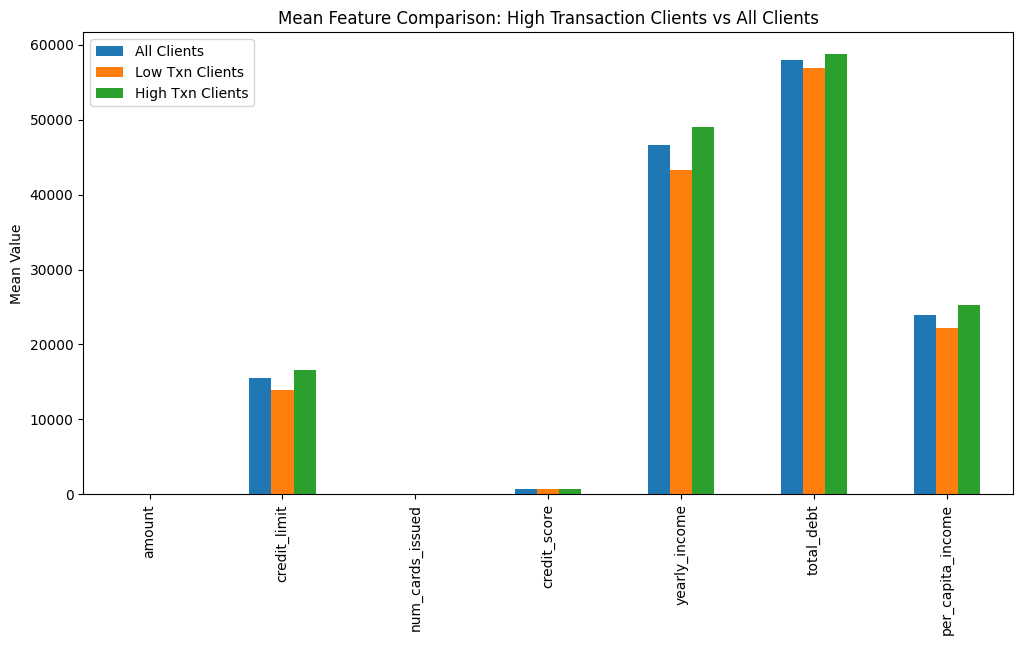

In [47]:
# High / Low / All 交易的狀態比較
avg_txn = client_txn_counts.mean()
print(f"Average transactions per client: {avg_txn:.2f}")

high_txn_clients = client_txn_counts[client_txn_counts > avg_txn].index
high_txn_data = Trans_merge[Trans_merge['client_id_txn'].isin(high_txn_clients)]
high_txn_stats = high_txn_data[features].describe()

below_txn_clients = client_txn_counts[client_txn_counts <= avg_txn].index
below_txn_data = Trans_merge[Trans_merge['client_id_txn'].isin(below_txn_clients)]
below_txn_stats = below_txn_data[features].describe()

all_txn_stats = Trans_merge[features].describe()

print("Statistics for clients with all transactions:")
print(all_txn_stats)
print("\nStatistics for clients with below-average transactions:")
print(below_txn_stats)
print("\nStatistics for clients with above-average transactions:")
print(high_txn_stats)

mean_stats = pd.DataFrame({
    'All Clients': all_txn_stats.loc['mean'],
    'Low Txn Clients': below_txn_stats.loc['mean'],
    'High Txn Clients': high_txn_stats.loc['mean']
})

mean_stats.plot(kind='bar', figsize=(12,6))
plt.title("Mean Feature Comparison: High Transaction Clients vs All Clients")
plt.ylabel("Mean Value")
plt.show()
plt.close()

In [49]:
# 五分鐘區間多筆交易分析
five_min_counts = Trans_merge.groupby(['client_id_txn', 'date_5min']).size().reset_index(name='txn_count_5min')

Trans_merge = Trans_merge.merge(five_min_counts, on=['client_id_txn', 'date_5min'], how='left')

Trans_merge['multi_txn_5min'] = Trans_merge['txn_count_5min'] > 3

multi_5min_count = Trans_merge['multi_txn_5min'].sum()
multi_5min_ratio = multi_5min_count / len(Trans_merge)
print(f"五分鐘內多筆交易（>3筆）共有 {multi_5min_count} 筆，佔全部交易 {multi_5min_ratio:.2%}")

五分鐘內多筆交易（>3筆）共有 3862 筆，佔全部交易 0.03%


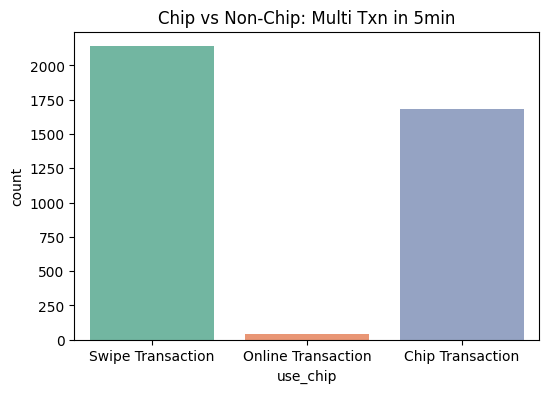

In [51]:
# 晶片 VS 非晶片
plt.figure(figsize=(6,4))
sns.countplot(x="use_chip", data=Trans_merge[Trans_merge['multi_txn_5min']], palette="Set2")
plt.title("Chip vs Non-Chip: Multi Txn in 5min")
plt.show()
plt.close()

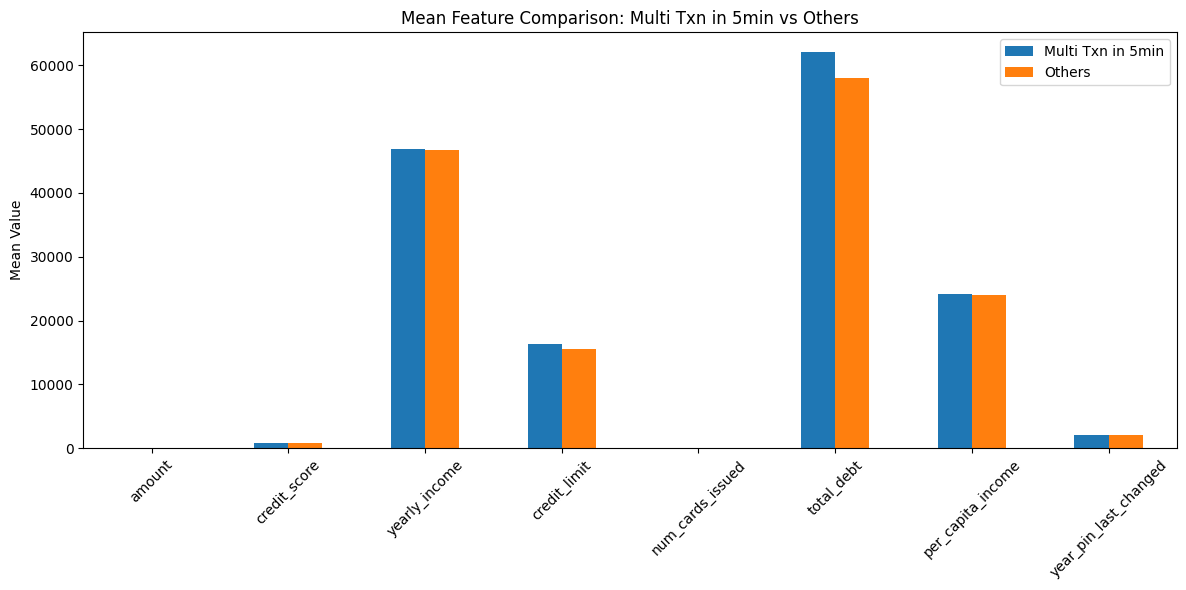

In [53]:
# 平均特徵比較
features_to_compare = ['amount', 'credit_score', 'yearly_income', 'credit_limit', 'num_cards_issued', 'total_debt', 'per_capita_income', 'year_pin_last_changed']
mean_multi = Trans_merge[Trans_merge['multi_txn_5min']][features_to_compare].mean()
mean_others = Trans_merge[~Trans_merge['multi_txn_5min']][features_to_compare].mean()
mean_stats = pd.DataFrame({
    'Multi Txn in 5min': mean_multi,
    'Others': mean_others
})
mean_stats.plot(kind='bar', figsize=(12,6))
plt.title("Mean Feature Comparison: Multi Txn in 5min vs Others")
plt.ylabel("Mean Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.close()

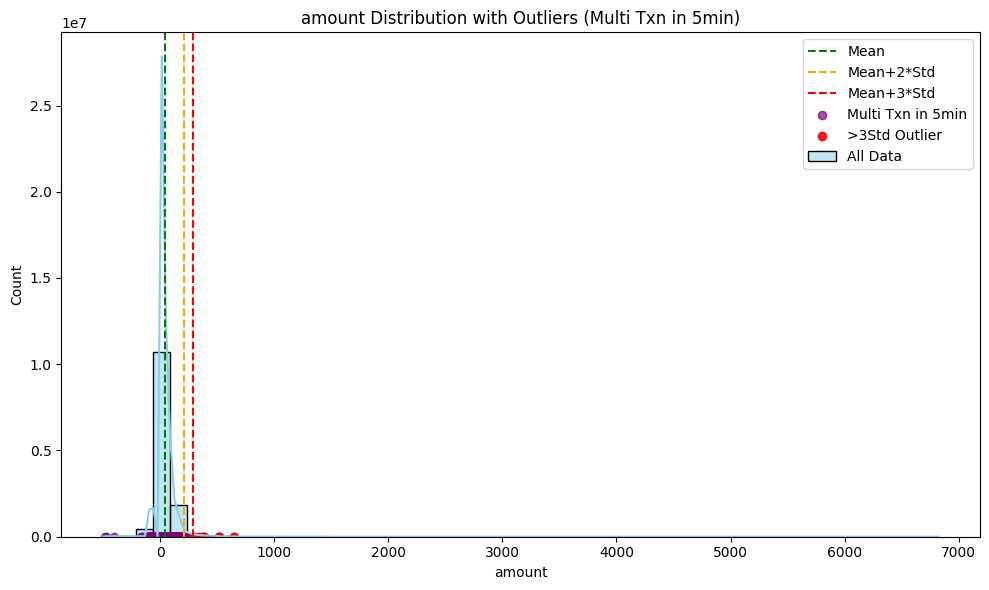

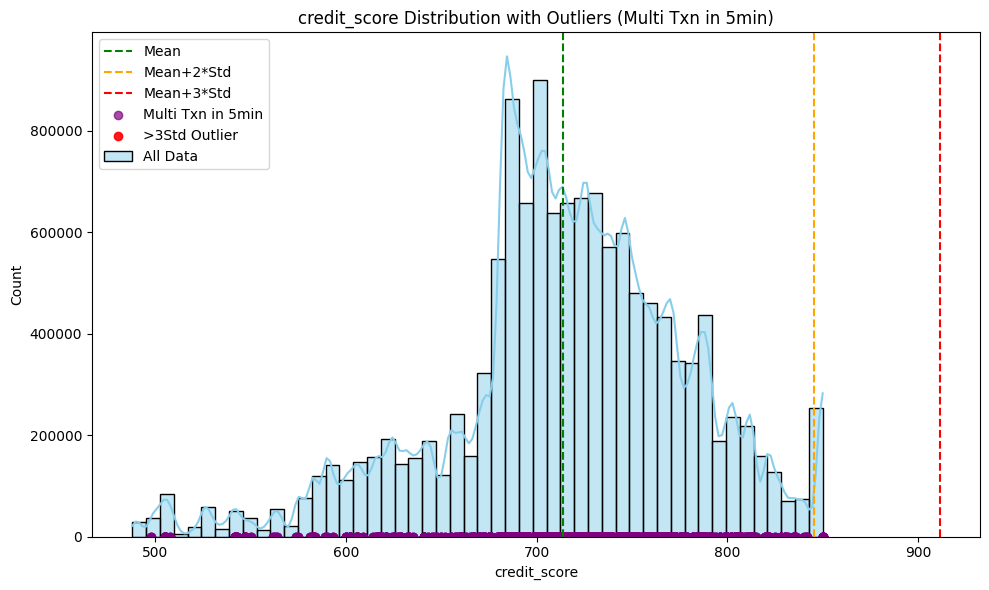

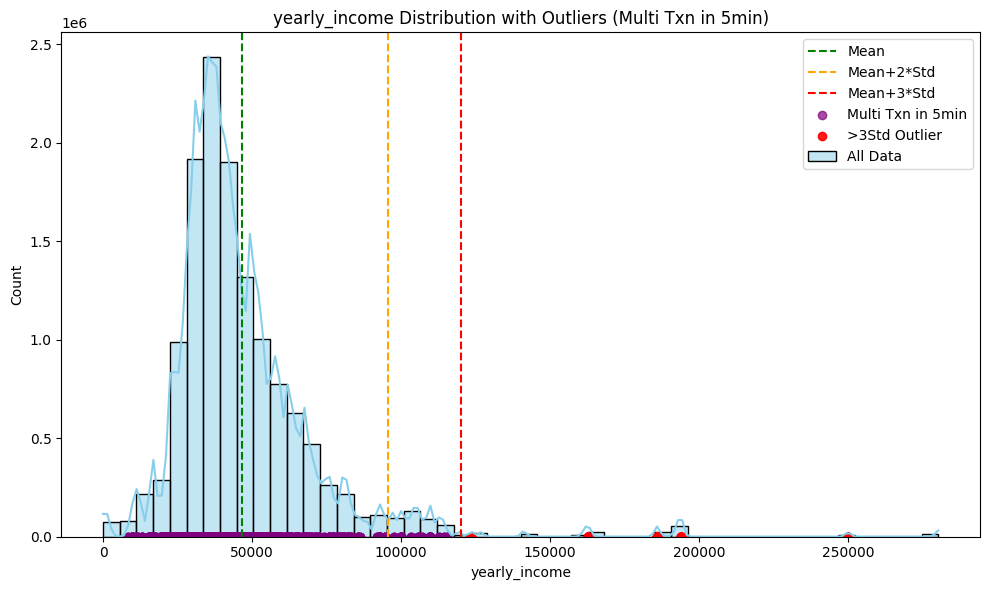

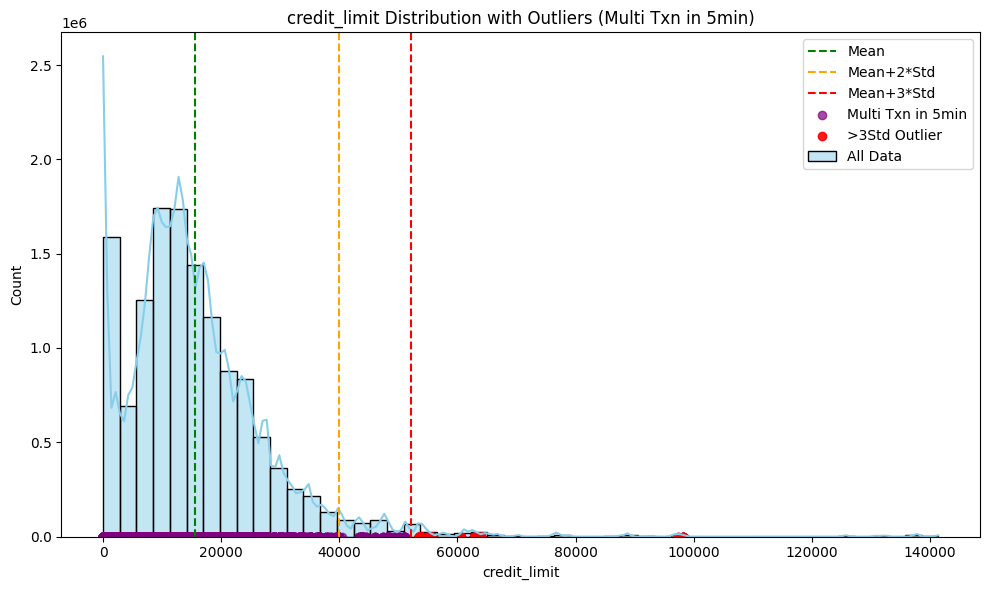

In [ ]:
# === 五分鐘內多筆交易特徵離群值分析與可視化 ===
features_to_compare = ['amount', 'credit_score', 'yearly_income', 'credit_limit', 'num_cards_issued', 'total_debt', 'per_capita_income', 'year_pin_last_changed']

multi_txn_data = Trans_merge[Trans_merge['multi_txn_5min']]

for feature in features_to_compare:
    mean = Trans_merge[feature].mean()
    std = Trans_merge[feature].std()
    threshold_2std = mean + 2 * std
    threshold_3std = mean + 3 * std
    # 離群值在該特徵上的值
    outlier_values = multi_txn_data[feature]
    # 判斷哪些離群值超過3個標準差
    outlier_mask = outlier_values > threshold_3std
    # 畫分布圖
    plt.figure(figsize=(10,6))
    sns.histplot(Trans_merge[feature], bins=50, kde=True, color='skyblue', label='All Data')
    # 標記均值、2std、3std
    plt.axvline(mean, color='green', linestyle='--', label='Mean')
    plt.axvline(threshold_2std, color='orange', linestyle='--', label='Mean+2*Std')
    plt.axvline(threshold_3std, color='red', linestyle='--', label='Mean+3*Std')
    # 標記離群值
    plt.scatter(outlier_values, np.full_like(outlier_values, 2), color='purple', label='Multi Txn in 5min', alpha=0.7)
    # 標記超過3std的離群值
    plt.scatter(outlier_values[outlier_mask], np.full_like(outlier_values[outlier_mask], 2), color='red', label='>3Std Outlier', alpha=0.9)
    plt.title(f"{feature} Distribution with Outliers (Multi Txn in 5min)")
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.legend()
    plt.tight_layout()
    plt.show()
    plt.close()